# Resample TEMPO L2 swath data onto a regular grid

In this code we demonstrate an example of resampling swath data onto a regular x,y grid using the `pyresample` library and [**NASA TEMPO NO2** L2 V4 (Tropospheric Emissions: Monitoring of Pollution Nitrogen Dioxide Level 2 Version 04)](https://www.earthdata.nasa.gov/data/catalog/larc-cloud-tempo-no2-l2-v04). 

This example also demonstrates how to perform the swath to grid resampling for an `xarray` dataset containing multiple data array variables.

#### Acknowledgements

Thanks to SARP 2026 student **Marin Stevens** for contributing the snippet idea!

## Setup

In [2]:
# Install pyresample
%pip install pyresample

Note: you may need to restart the kernel to use updated packages.


In [3]:
import earthaccess
import xarray as xr
import rioxarray
from pathlib import Path
from datetime import datetime, date
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import psutil
import os
import warnings
import gc
import numpy as np
import geopandas as gpd
from shapely import box
from pyproj import Transformer
warnings.filterwarnings("ignore")

import pyresample
from pyresample.area_config import create_area_def
from pyresample.geometry import AreaDefinition
from pyresample import kd_tree, geometry
from pyresample.bilinear import XArrayBilinearResampler

In [4]:
# Login using your credentials - your user name and password for NASA EarthData
earthaccess.login()

## Data streaming

In [16]:
var_names = ['vertical_column_troposphere', 'eff_cloud_fraction']
xmin, ymin, xmax, ymax = -95.6, 28.9, -94.5, 30
start_date, end_date = "2024-07-01", "2024-07-01"

In [17]:
results = earthaccess.search_data(
    short_name='TEMPO_NO2_L2',
    bounding_box=(xmin, ymin, xmax, ymax),
    temporal=(start_date, end_date),
    version="V04"
)
print(f'Search returned {len(results)} results')

Search returned 21 results


In [18]:
# Stream the results
streamed = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/21 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/21 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/21 [00:00<?, ?it/s]

## Data pre-processing
* Open the dataset, get the variables of interest and set the lat and lon coords
* Mask the swath data approximately to the area of interest
* Add the time variables
* Just performed here for one data file but could be performed in a loop on all data files which can then be stacked over the time dimension

In [19]:
# Empty list to store the opened and pre-processed swath datasets
streamed_file = streamed[0]

# Open the variables of interest, the geolocation (lat/lon) data, merge and set the coords
ds_geoloc = xr.open_dataset(streamed_file, group="geolocation", engine="h5netcdf")
ds_product = xr.open_dataset(streamed_file, group="product", engine="h5netcdf")
ds_support = xr.open_dataset(streamed_file, group="support_data", engine="h5netcdf")
ds = xr.merge([ds_product, ds_geoloc, ds_support],compat="override")[var_names]
ds = ds.set_coords(["latitude","longitude"])

# Mask the data to the bounding area
mask = ((ds['longitude'] >= xmin) &
        (ds['longitude'] <= xmax) &
        (ds['latitude'] >= ymin) &
        (ds['latitude'] <= ymax))
ds=ds.where(mask, drop=True)

# Set time to the mean of the small time increments in the dataset
ds['time'] = ds.time.mean()

## Resampling from swath to gridded
See the original swath to gridded [example](https://github.com/NASA-SARP/2026-Coding-Alex/blob/main/snippets/resample_swath_data_to_grid.ipynb) for more description

In [20]:
# Set up pyproj transformer to convert from lat/lon degrees to web mercator in meters
target_crs = 'EPSG:4326'
target_res = 0.02 # based on the L3 TEMPO product
target_units = "degrees"

# Transformer not strictly needed here since projecting from 4326 to 4326
transformer = Transformer.from_crs(4326, target_crs, always_xy=True)

In [21]:
# Transform the original lat/lon coordinate values to web mercator in meters
x, y = transformer.transform(ds.longitude.values,
                             ds.latitude.values)

# Print the approximate original average spatial resolution of the swath data 
dx = np.nanmedian(np.abs(np.diff(x)))
dy = np.nanmedian(np.abs(np.diff(y)))

print(f'Approximate spatial resolution of original swath data (x, y) in {target_units}: {dx:.5f}, {dy:.5f}')

# Get the bounding extent in the reprojected CRS
xmin_reproj, ymin_reproj, xmax_reproj, ymax_reproj = np.nanmin(x), np.nanmin(y), np.nanmax(x), np.nanmax(y)
print(f'Creating target AreaDefinition for area: ({xmin_reproj:.5f}, {ymin_reproj:.5f}, {xmax_reproj:.5f}, {ymax_reproj:.5f}) at {target_res} {target_units} target resolution')

# Create pyresample AreaDefinition: the target regular grid
area_def = create_area_def(
    area_id="mercator",
    projection=target_crs,
    area_extent=(xmin_reproj, ymin_reproj, xmax_reproj, ymax_reproj),
    resolution=target_res,
    units=target_units)

# Create pyresample SwathDefinition: the source irregular swath
swath_def = pyresample.SwathDefinition(lons=ds.longitude.values, lats=ds.latitude.values)

# Define the data values to use - numpy array required
# Stack the two data array variables
data = np.dstack([ds[var_names[0]].to_numpy(),
                 ds[var_names[1]].to_numpy()])
print(f'Shape of original swath data: {data.shape}')

# Check the number of na versus filled values in the original swath data
filled_fraction = np.isfinite(data).sum() / data.size
print(f"Original swath data contains {100 * filled_fraction:.1f}% filled values")

shape found from radius and resolution does not contain only integers: (54.8683166503918, 51.62239074708058)
Rounding shape to (55, 52) and resolution from (0.01999999999999602, 0.019999999999999574) meters to (0.01985476567195012, 0.01995211514559659) meters


Approximate spatial resolution of original swath data (x, y) in degrees: 0.00076, 0.01679
Creating target AreaDefinition for area: (-95.53278, 28.90000, -94.50033, 29.99736) at 0.02 degrees target resolution
Shape of original swath data: (21, 66, 2)
Original swath data contains 99.9% filled values


In [22]:
# Calculate radius of influence
if target_units=='meters':
    # projected CRS with metric units
    radius_of_influence = target_res * 2

else:
    # geographic CRS in degrees
    # approximate conversion using latitude scale
    mean_lat = float(np.nanmean(ds.latitude))

    meters_per_degree_lat = 111_320
    meters_per_degree_lon = meters_per_degree_lat * np.cos(np.deg2rad(mean_lat))

    # convert target resolution in degrees to approximate meters
    target_res_m = target_res * np.mean([meters_per_degree_lat, meters_per_degree_lon])

    radius_of_influence = target_res_m * 2
print(f'Estimate radius of influence to use (in meters): {radius_of_influence}')

Estimate radius of influence to use (in meters): 4165.167459406849


In [23]:
# Resample using kd_tree nearest neighbor resampling
process_start = datetime.now() 
data_gridded = kd_tree.resample_nearest(swath_def,  # source SwathDefinition
                                  data, # Values
                                  area_def, # target AreaDefinition
                                  radius_of_influence=radius_of_influence, 
                                  fill_value=np.nan) #epsilon=0.5, 
print(f'Shape of output regular gridded data: {data_gridded.shape}')
print(f'Approx. ratio of N output regular grid pixels to N input swath pixels: {data_gridded.size / data.size}')

# Check the number of na versus filled values in the resulting gridded data
filled_fraction = np.isfinite(data_gridded).sum() / data_gridded.size
print(f"Output gridded data contains {100 * filled_fraction:.1f}% filled values")

# Get current RAM usage
process = psutil.Process(os.getpid())
print(f'memory usage {process.memory_info().rss / 1024**3} GB')

# Print time it took for the processing
process_time = datetime.now() - process_start
print(f'Process took {process_time.seconds / 60} minutes')

Shape of output regular gridded data: (55, 52, 2)
Approx. ratio of N output regular grid pixels to N input swath pixels: 2.0634920634920637
Output gridded data contains 99.9% filled values
memory usage 4.759010314941406 GB
Process took 0.0 minutes


In [32]:
# Create output regular gridded Dataset
x_gridded = area_def.projection_x_coords
y_gridded = area_def.projection_y_coords

# Loop over the variables
# For each variable, create data array with the gridded values
data_vars = {}
for i, var_name in enumerate(var_names):
    da = xr.DataArray(
        data_gridded[:, :, i],
        dims=("y", "x"),
        coords={"x": x_gridded,
                "y": y_gridded,},
        name=var_name,)

    da = (da.rio.set_spatial_dims(x_dim="x", y_dim="y")
          .sortby("y")
          .rio.write_crs(area_def.crs))

    data_vars[var_name] = da

# Create dataset from the dictionary of data arrays
ds_gridded = xr.Dataset(data_vars)
ds_gridded

<xarray.Dataset> Size: 47kB
Dimensions:                      (x: 52, y: 55)
Coordinates:
  * x                            (x) float64 416B -95.52 -95.5 ... -94.53 -94.51
  * y                            (y) float64 440B 28.91 28.93 ... 29.97 29.99
    spatial_ref                  int64 8B 0
Data variables:
    vertical_column_troposphere  (y, x) float64 23kB nan 9.101e+13 ... 1.071e+15
    eff_cloud_fraction           (y, x) float64 23kB nan 0.03813 ... 0.03723

## Plot the result

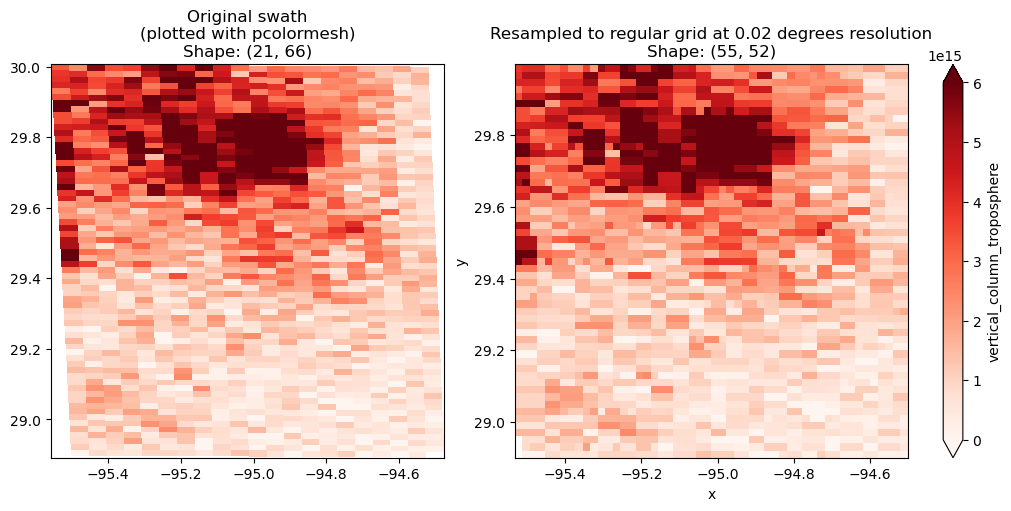

In [33]:
var_to_plot = 'vertical_column_troposphere'
cmap, vmin, vmax = 'Reds', 0, 6e15
fig, axes = plt.subplots(1, 2, figsize=(10,5), constrained_layout=True)

axes[0].pcolormesh(
    ds.longitude,
    ds.latitude,
    ds[var_to_plot],
    shading="auto",
    cmap=cmap, vmin=vmin, vmax=vmax)

ds_gridded[var_to_plot].plot(ax=axes[1], cmap=cmap, vmin=vmin, vmax=vmax)

axes[0].set_title(f'Original swath\n(plotted with pcolormesh)\nShape: {ds[var_to_plot].shape}')
axes[1].set_title(f'Resampled to regular grid at {target_res} {target_units} resolution\nShape: {ds_gridded[var_to_plot].shape}')
    
plt.show()